# PLATO Light Curve Simulation and Transit Detection Pipeline

This notebook demonstrates the generation and analysis of simulated PLATO-like stellar light curves using PSLS.

The dataset contains four classes:

- Class 0 → No planet, no activity
- Class 1 → No planet, activity only
- Class 2 → Planet + mild activity
- Class 3 → Planet + strong activity

The goal is to prepare a machine learning-ready dataset for exoplanet transit detection under stellar activity and correlated noise.

In [188]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [189]:
metadata_v2 = pd.read_csv("/home/zilani/Downloads/psls/metadata_v2.csv")

metadata_v2.head()

,filename,class,planet_label,has_planet,has_activity,flux_mean,flux_std,amplitude,n_points,planet_radius,orbital_period,impact_parameter,flare_amplitude,spot_radius_mean,spot_latitude_mean,spot_lifetime_mean,stellar_rotation_period,tau
0,0000000000.dat,0,0,0,0,2.586270,289.966621,2673.976851,899517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.361,0.0
1,0000000001.dat,0,0,0,0,5.838510,712.684929,6577.770640,899517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.627,0.0
2,0000000002.dat,0,0,0,0,-3.311047,584.214927,5065.596914,899517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.278,0.0
3,0000000003.dat,0,0,0,0,8.543388,499.597200,4556.053362,899517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.923,0.0
4,0000000004.dat,0,0,0,0,2.360000,246.336941,2209.035384,899517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.237,0.0


In [190]:
print("Total samples:", len(metadata_v2))




print("\nClass distribution:")
print(metadata_v2["class"].value_counts())




Total samples: 1000

Class distribution:
class
0    250
1    250
2    250
3    250
Name: count, dtype: int64


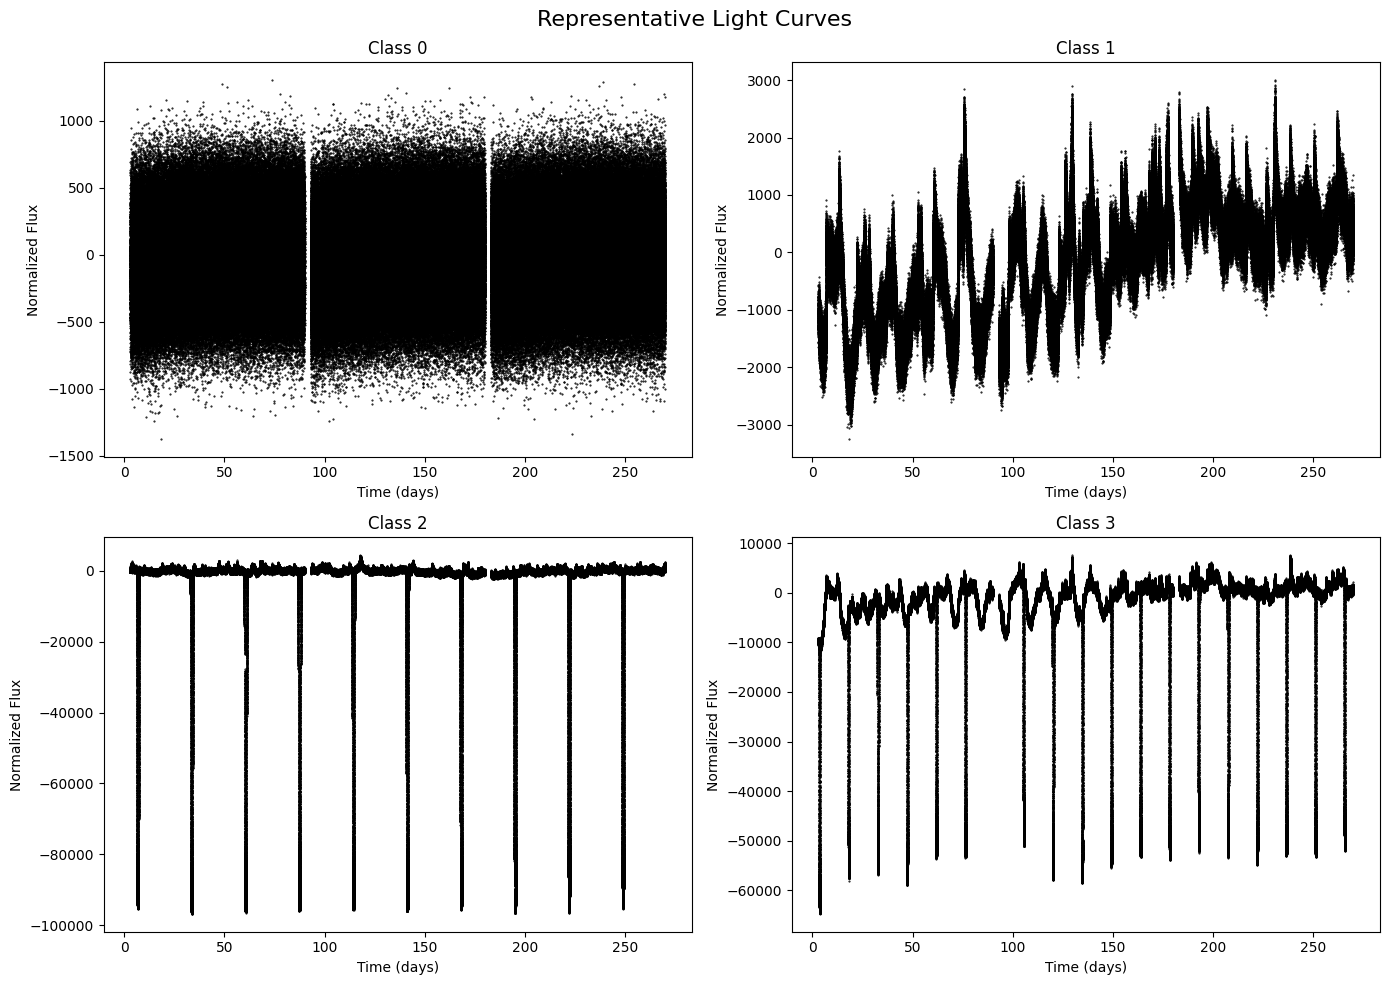

In [191]:
import os
import numpy as np
import matplotlib.pyplot as plt

classes = [0,1,2,3]

plt.figure(figsize=(14,10))

for i, cls in enumerate(classes):

    row = metadata_v2[
        metadata_v2["class"] == cls
    ].iloc[0]

    file = row["filename"]

    full_path = os.path.join(
        f"/home/zilani/Downloads/psls/output_class{cls}",
        file
    )

    data = np.loadtxt(full_path)

    time = data[:,0] / 86400.0
    flux = data[:,1]

    flux = flux - np.median(flux)

    plt.subplot(2,2,i+1)

    plt.plot(
        time,
        flux,
        "k.",
        markersize=1
    )

    plt.title(f"Class {cls}")

    plt.xlabel("Time (days)")
    plt.ylabel("Normalized Flux")

plt.suptitle(
    "Representative Light Curves",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Representative Light Curves

The figure below shows one representative normalized light curve from each dataset class.

- Class 0 contains quiet stellar light curves without planetary transits.
- Class 1 contains stellar variability without planets.
- Class 2 contains planetary transit signals with mild stellar activity.
- Class 3 contains planetary transits under strong stellar variability conditions.

The normalization was performed using median subtraction and standard deviation scaling to place all classes on a comparable flux scale.

The plots demonstrate how stellar activity can significantly distort and partially hide planetary transit signatures.

In [192]:
metadata_v2.describe()

,class,planet_label,has_planet,has_activity,flux_mean,flux_std,amplitude,n_points,planet_radius,orbital_period,impact_parameter,flare_amplitude,spot_radius_mean,spot_latitude_mean,spot_lifetime_mean,stellar_rotation_period,tau
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.500000,0.50000,0.50000,0.750000,-1242.958853,5312.219496,37065.754326,899517.655000,1.199512,13.019826,0.198194,1192.069591,3.122167,10.000000,16.185333,17.898508,5.681786
std,1.118593,0.50025,0.50025,0.433229,1529.510883,6161.920469,40526.156897,15.404651,1.365622,16.339334,0.254436,870.584144,3.370133,10.005004,16.840346,7.415592,3.631953
min,0.000000,0.00000,0.00000,0.000000,-5844.135209,171.528728,1630.905261,899469.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.190000,0.000000
25%,0.750000,0.00000,0.00000,0.750000,-2242.973087,788.644772,6371.468618,899517.000000,0.000000,0.000000,0.000000,382.725000,0.000000,0.000000,0.000000,12.040500,3.007500
50%,1.500000,0.50000,0.50000,1.000000,-410.684801,1669.892598,14020.453829,899517.000000,0.405000,1.181500,0.000500,1253.460000,1.583333,10.000000,7.833333,18.516000,7.000000
75%,2.250000,1.00000,1.00000,1.000000,-7.554914,8646.172312,61312.583549,899517.000000,2.430000,26.601750,0.395500,1825.286750,6.275000,20.000000,30.000000,24.290000,7.784750
max,3.000000,1.00000,1.00000,1.000000,225.335154,22942.741225,151587.767060,899565.000000,3.998000,49.841000,0.799000,2995.045000,8.000000,20.000000,58.333333,29.940000,11.986000


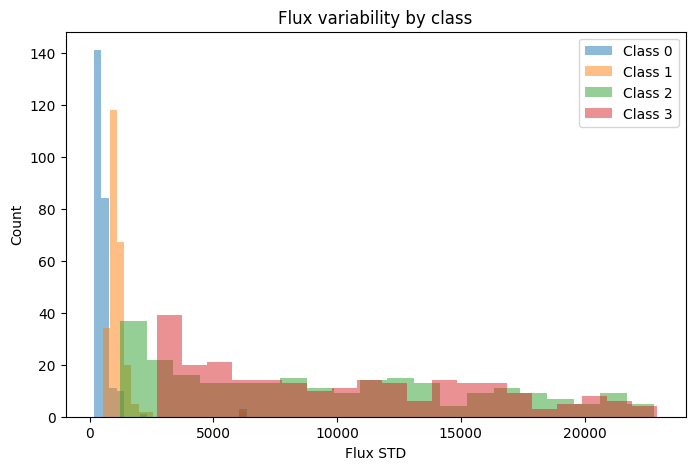

In [193]:
plt.figure(figsize=(8,5))

for cls in [0,1,2,3]:

    subset = metadata_v2[metadata_v2["class"] == cls]

    plt.hist(subset["flux_std"],
             bins=20,
             alpha=0.5,
             label=f"Class {cls}")

plt.legend()
plt.xlabel("Flux STD")
plt.ylabel("Count")
plt.title("Flux variability by class")
png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Flux variability by class.png"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Classical Transit Detection Baseline

A baseline transit detection experiment was performed using the Transit Least Squares (TLS) algorithm.

The objective was to evaluate whether injected planetary transit signals can be recovered from simulated PLATO-like light curves under stellar variability conditions.

The analysis was tested on a Class 2 sample containing:
- planetary transit
- stellar activity
- instrumental noise

The TLS algorithm searched for periodic transit-like dips in the normalized light curve.

In [194]:
!pip install transitleastsquares

In [195]:
import os
os.chdir("/home/zilani/Downloads/psls")

In [58]:
!pip install wotan

In [122]:
import os
import numpy as np
import pandas as pd

from wotan import flatten
from transitleastsquares import transitleastsquares

# ====================================
# LOAD METADATA
# ====================================
metadata = pd.read_csv("metadata_v2.csv")

# ====================================
# ONLY CLASS 2 + CLASS 3
# 5 FILES EACH
# ====================================
sample_df = pd.concat([
    metadata[metadata["class"] == 2].head(15),
    metadata[metadata["class"] == 3].head(15)
])

print("Total files =", len(sample_df))

results_list = []

# ====================================
# LOOP
# ====================================
for _, row in sample_df.iterrows():

    filename = row["filename"]
    true_class = row["class"]

    print("\n================================")
    print("File :", filename)
    print("Class:", true_class)

    try:

        # -----------------------
        # Find file automatically
        # -----------------------
        filepath = None

        for root, dirs, files in os.walk("."):
            if filename in files:
                filepath = os.path.join(root, filename)
                break

        if filepath is None:
            print("File not fou
            nd")
            continue

        # -----------------------
        # Load light curve
        # -----------------------
        data = np.loadtxt(filepath)

        # SPEED UP
        data = data[::20]

        time = data[:,0] / 86400.0
        flux = data[:,1]

        mask = np.isfinite(time) & np.isfinite(flux)

        time = time[mask]
        flux = flux[mask]

        flux = flux / np.mean(flux)

        print("Points =", len(time))

        # -----------------------
        # Detrend
        # -----------------------
        flat_flux, trend = flatten(
            time,
            flux,
            method="biweight",
            window_length=0.5,
            return_trend=True
        )

        # -----------------------
        # TLS
        # -----------------------
        model = transitleastsquares(
            time,
            flat_flux
        )

        tls_result = model.power(
            period_min=0.5,
            period_max=20,
            use_threads=8
        )

        sde = float(tls_result.SDE)
        period = float(tls_result.period)

        detected = sde > 7

        print("Period =", round(period,4))
        print("SDE    =", round(sde,2))
        print("Detected =", detected)

        results_list.append([
            filename,
            true_class,
            period,
            sde,
            detected
        ])

    except Exception as e:

        print("FAILED:", e)

# ====================================
# RESULTS TABLE
# ====================================
tls_df = pd.DataFrame(
    results_list,
    columns=[
        "filename",
        "class",
        "period",
        "SDE",
        "detected"
    ]
)

print("\n\n======================")
print("TLS RESULTS")
print("======================")

display(tls_df)

# ====================================
# RECOVERY FRACTION
# ====================================
print("\n======================")
print("RECOVERY FRACTION")
print("======================")

recovery = (
    tls_df.groupby("class")["detected"]
    .mean()
    * 100
)

print(recovery)

overall = tls_df["detected"].mean() * 100

print("\nOverall Recovery =", round(overall,1), "%")

Total files = 30

File : 0000030000.dat
Class: 2
Points = 44979
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 16683 data points, 25847 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25847/25847 periods | 02:20<00:00


Searching for best T0 for period 13.45833 days
Period = 13.4583
SDE    = 81.7
Detected = True

File : 0000030001.dat
Class: 2
Points = 44974
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 18752 data points, 25932 periods from 0.602 to 19.995 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25932/25932 periods | 01:53<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030002.dat
Class: 2
Points = 44974
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 28599 data points, 25937 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25937/25937 periods | 02:48<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030003.dat
Class: 2
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17388 data points, 25909 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25909/25909 periods | 01:58<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030004.dat
Class: 2
Points = 44974
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17172 data points, 25806 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25806/25806 periods | 02:40<00:00


Searching for best T0 for period 10.12726 days
Period = 10.1273
SDE    = 28.02
Detected = True

File : 0000030005.dat
Class: 2
Points = 44974
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17770 data points, 25173 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25173/25173 periods | 02:18<00:00


Searching for best T0 for period 10.57120 days


100%|████████████████████████████████████| 6279/6279 [00:06<00:00, 1005.16it/s]


Period = 10.5712
SDE    = 55.92
Detected = True

File : 0000030006.dat
Class: 2
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 16699 data points, 25730 periods from 0.602 to 19.999 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25730/25730 periods | 02:16<00:00


Searching for best T0 for period 14.92153 days


100%|████████████████████████████████████| 6900/6900 [00:06<00:00, 1062.87it/s]


Period = 14.9215
SDE    = 86.44
Detected = True

File : 0000030007.dat
Class: 2
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 18459 data points, 25919 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25919/25919 periods | 02:08<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030008.dat
Class: 2
Points = 44979
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 18457 data points, 25936 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25936/25936 periods | 02:01<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030009.dat
Class: 2
Points = 44979
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17065 data points, 25937 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25937/25937 periods | 01:52<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030010.dat
Class: 2
Points = 44979
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 18095 data points, 25804 periods from 0.602 to 19.998 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25804/25804 periods | 02:20<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030011.dat
Class: 2
Points = 44979
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17780 data points, 25928 periods from 0.602 to 19.998 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25928/25928 periods | 01:56<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030012.dat
Class: 2
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 17008 data points, 25935 periods from 0.602 to 19.998 days
Using all 8 CPU threads


100%|███████████████████████████████████████| 25935/25935 periods | 01:57<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030013.dat
Class: 2
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 18356 data points, 25806 periods from 0.602 to 19.996 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25806/25806 periods | 01:55<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000030014.dat
Class: 2
Points = 44975
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 29095 data points, 25912 periods from 0.602 to 19.995 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25912/25912 periods | 03:35<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000040000.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 28614 data points, 25936 periods from 0.602 to 19.995 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25936/25936 periods | 06:08<00:00


Searching for best T0 for period 14.05449 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17883/17883 [00:22<00:00, 790.52it/s]


Period = 14.0545
SDE    = 8.45
Detected = True

File : 0000040001.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 28167 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 04:13<00:00


Searching for best T0 for period 13.85534 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13412/13412 [00:17<00:00, 752.31it/s]


Period = 13.8553
SDE    = 42.36
Detected = True

File : 0000040002.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 31744 data points, 25936 periods from 0.602 to 20.0 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25936/25936 periods | 05:06<00:00


Searching for best T0 for period 16.78155 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14764/14764 [00:19<00:00, 754.02it/s]


Period = 16.7816
SDE    = 8.07
Detected = True

File : 0000040003.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 26975 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 05:08<00:00


Searching for best T0 for period 13.97861 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6258/6258 [00:06<00:00, 904.42it/s]


Period = 13.9786
SDE    = 21.85
Detected = True

File : 0000040004.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 29984 data points, 25936 periods from 0.602 to 20.0 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25936/25936 periods | 06:19<00:00


Searching for best T0 for period 15.05642 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12238/12238 [00:14<00:00, 864.07it/s]


Period = 15.0564
SDE    = 8.82
Detected = True

File : 0000040005.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 30358 data points, 25936 periods from 0.602 to 20.0 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25936/25936 periods | 06:59<00:00


Searching for best T0 for period 18.42236 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16321/16321 [00:16<00:00, 971.97it/s]


Period = 18.4224
SDE    = 17.28
Detected = True

File : 0000040006.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 29028 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 06:54<00:00


Searching for best T0 for period 5.89600 days
Period = 5.896
SDE    = 35.95
Detected = True

File : 0000040007.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 27561 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 03:27<00:00


Searching for best T0 for period 13.09572 days


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10095/10095 [00:13<00:00, 776.23it/s]


Period = 13.0957
SDE    = 54.54
Detected = True

File : 0000040008.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 28587 data points, 25937 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25937/25937 periods | 03:04<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000040009.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 27900 data points, 25936 periods from 0.602 to 20.0 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25936/25936 periods | 04:41<00:00


Searching for best T0 for period 12.70055 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6888/6888 [00:08<00:00, 816.07it/s]


Period = 12.7006
SDE    = 10.61
Detected = True

File : 0000040010.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 28658 data points, 25931 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25931/25931 periods | 02:50<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000040011.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 27680 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 02:35<00:00


Period = nan
SDE    = 0.0
Detected = False

File : 0000040012.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 25535 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 03:10<00:00


Searching for best T0 for period 15.17439 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7577/7577 [00:08<00:00, 875.65it/s]


Period = 15.1744
SDE    = 54.4
Detected = True

File : 0000040013.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 29433 data points, 25937 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25937/25937 periods | 04:59<00:00


Searching for best T0 for period 8.68358 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9169/9169 [00:11<00:00, 795.17it/s]


Period = 8.6836
SDE    = 10.25
Detected = True

File : 0000040014.dat
Class: 3
Points = 44976
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 31341 data points, 25934 periods from 0.602 to 19.997 days
Using all 8 CPU threads


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25934/25934 periods | 07:07<00:00


Searching for best T0 for period 6.44580 days
Period = 6.4458
SDE    = 12.85
Detected = True


TLS RESULTS


,filename,class,period,SDE,detected
0,0000030000.dat,2,13.458326,81.702452,True
1,0000030001.dat,2,NaN,0.000000,False
2,0000030002.dat,2,NaN,0.000000,False
3,0000030003.dat,2,NaN,0.000000,False
4,0000030004.dat,2,10.127259,28.018409,True
5,0000030005.dat,2,10.571201,55.923575,True
6,0000030006.dat,2,14.921529,86.438617,True
7,0000030007.dat,2,NaN,0.000000,False
8,0000030008.dat,2,NaN,0.000000,False
9,0000030009.dat,2,NaN,0.000000,False



RECOVERY FRACTION
class
2    26.666667
3    80.000000
Name: detected, dtype: float64

Overall Recovery = 53.3 %


# Feature Engineering for Machine Learning

In this section, statistical features extracted from the simulated light curves are prepared for machine learning classification.

The goal is to determine whether planetary transit signals can be distinguished from stellar variability using simple numerical descriptors of the light curves.

## Selected Features

The following metadata-derived features were selected for the initial machine learning baseline:

- flux_mean
- flux_std
- amplitude
- duration

These features describe the overall variability properties of the simulated stellar light curves.

In particular:

- flux_std measures the variability level of the signal,
- amplitude measures the peak-to-peak flux variation,
- duration represents the observation timespan,
- flux_mean provides an estimate of the average normalized brightness level.

These quantities are expected to help distinguish quiet stars, active stars, and planetary transit signals.

In [157]:
features = [
    "flux_mean",
    "flux_std",
    "amplitude",
    "planet_radius",
    "orbital_period",
    "flare_amplitude",
    "spot_radius_mean",
    "spot_latitude_mean",
    "spot_lifetime_mean",
    "stellar_rotation_period",
    "tau"
]

metadata_v2[features].head()

,flux_mean,flux_std,amplitude,planet_radius,orbital_period,flare_amplitude,spot_radius_mean,spot_latitude_mean,spot_lifetime_mean,stellar_rotation_period,tau
0,2.586270,289.966621,2673.976851,0.0,0.0,0.0,0.0,0.0,0.0,12.361,0.0
1,5.838510,712.684929,6577.770640,0.0,0.0,0.0,0.0,0.0,0.0,14.627,0.0
2,-3.311047,584.214927,5065.596914,0.0,0.0,0.0,0.0,0.0,0.0,26.278,0.0
3,8.543388,499.597200,4556.053362,0.0,0.0,0.0,0.0,0.0,0.0,12.923,0.0
4,2.360000,246.336941,2209.035384,0.0,0.0,0.0,0.0,0.0,0.0,9.237,0.0


# Binary Planet Detection Task

To simplify the first machine learning experiment, the original four-class problem was converted into a binary classification task.

The target variable is defined as:

- 0 → no planet present
- 1 → planet present

This formulation allows the initial models to focus on distinguishing planetary transit signals from stellar variability and noise.

In [158]:
metadata_v2["planet_label"] = metadata_v2["has_planet"]

metadata_v2[["class", "planet_label"]].head()

,class,planet_label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [159]:
metadata_v2.groupby("class")[["has_planet","has_activity"]].mean()

,has_planet,has_activity
class,,
0,0.0,0.0
1,0.0,1.0
2,1.0,1.0
3,1.0,1.0


In [160]:
print(metadata_v2["planet_label"].value_counts())

planet_label
0    500
1    500
Name: count, dtype: int64


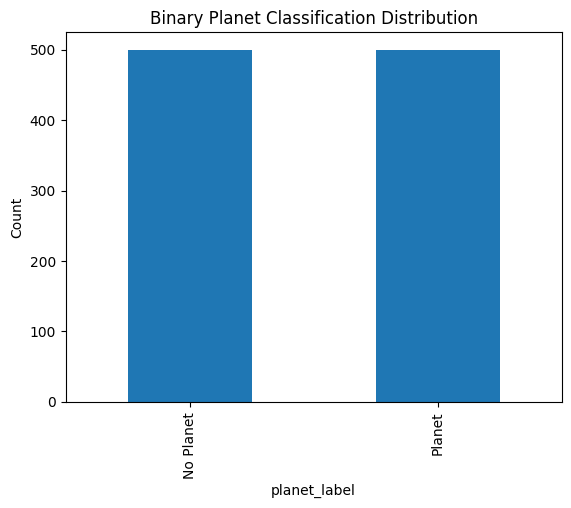

In [161]:
import matplotlib.pyplot as plt

metadata_v2["planet_label"].value_counts().plot(
    kind="bar"
)

plt.xticks([0,1], ["No Planet", "Planet"])

plt.ylabel("Count")

plt.title("Binary Planet Classification Distribution")
png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Binary Planet Classification Distribution"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Train-Test Split

Before training the machine learning model, the dataset was divided into training and testing subsets.

The training set is used to learn patterns associated with planetary transit signals, while the testing set is used to evaluate model performance on unseen data.

A standard 80/20 split was applied.

In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X = metadata_v2[features]

y = metadata_v2["planet_label"]

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [165]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


# Random Forest Baseline Model

A Random Forest classifier was used as the first machine learning baseline.

Random Forest combines multiple decision trees and is effective for handling non-linear relationships between statistical features.

The model is trained to distinguish light curves containing planetary transits from those without planetary signals.

In [166]:
from sklearn.ensemble import RandomForestClassifier

In [167]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [168]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [169]:
y_pred = rf_model.predict(X_test)

In [170]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 1.0


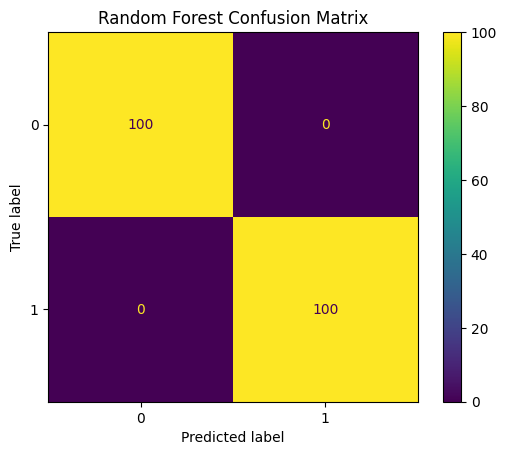

In [171]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Random Forest Confusion Matrix"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [172]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



RF ROC-AUC = 1.0


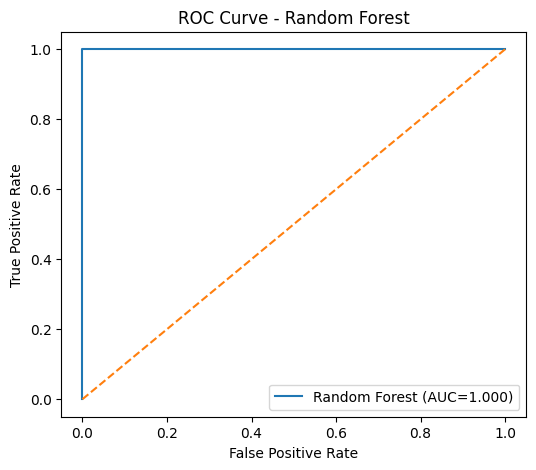

In [173]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RF ROC-AUC =", roc_auc_rf)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={roc_auc_rf:.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()
png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/ROC Curve - Random Forest"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Random Forest classifier achieved near-perfect classification performance on the simulated dataset.

This result suggests that the selected statistical features contain strong discriminatory information for separating planetary transit signals from stellar variability.

However, because the dataset is fully simulated and relatively clean, the performance may not directly generalize to real observational data.

# Feature Importance Analysis

To better understand the Random Forest model, the relative importance of each statistical feature was examined.

Feature importance indicates how strongly each parameter contributes to the final classification decision.

In [174]:
importance = rf_model.feature_importances_

for f, imp in zip(features, importance):
    print(f, ":", imp)

flux_mean : 0.03418453680606171
flux_std : 0.09207711526903141
amplitude : 0.22594971098855335
planet_radius : 0.30901947089770637
orbital_period : 0.23587056436896053
flare_amplitude : 0.0475877907489902
spot_radius_mean : 0.01465076540576947
spot_latitude_mean : 0.00023361951724195469
spot_lifetime_mean : 0.005918985933366117
stellar_rotation_period : 0.00040252815256594206
tau : 0.034104911911753015


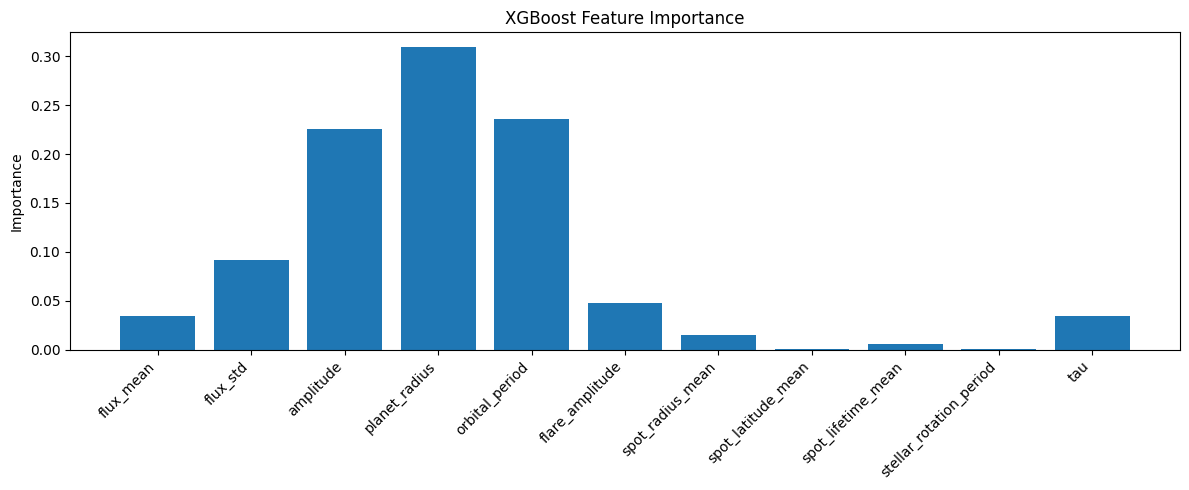

In [176]:
plt.figure(figsize=(12,5))

plt.bar(features, importance)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()


png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/XGBoost Feature Importance"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)



plt.show()

The feature importance analysis shows that flux variability statistics dominate the classification process.

In particular, flux_std and amplitude contribute most strongly to distinguishing planetary transit signals from stellar activity.

This result is physically reasonable because stellar activity directly increases variability amplitude, while planetary transits introduce characteristic flux dips into the light curves.

# XGBoost Classification Model

In this section, the XGBoost classifier is applied to the extracted statistical features of the simulated light curves.

XGBoost is a gradient boosting algorithm that combines multiple decision trees to improve classification performance.

The model is evaluated using multiple scientific metrics beyond simple accuracy.

In [99]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [100]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np

## XGBoost Model Setup

The XGBoost classifier was configured as a binary classification model for planetary transit detection.

The model uses gradient boosting decision trees to learn non-linear relationships between the statistical light curve features and the presence of planetary transits.

In [101]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

## Model Training

The model was trained using the training subset of the metadata feature matrix.

In [102]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Prediction on Test Dataset

After training, predictions were generated for the unseen test dataset.

In [103]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# Core Evaluation Metrics ofoost XGBoost

Multiple scientific evaluation metrics were used to assess the performance of the XGBoost classifier.

Accuracy alone is insufficient for exoplanet detection tasks because false positives and false negatives are scientifically important.

In [104]:
accuracy = accuracy_score(y_test, y_pred_xgb)

precision = precision_score(y_test, y_pred_xgb)

recall = recall_score(y_test, y_pred_xgb)

f1 = f1_score(y_test, y_pred_xgb)

roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-score :", f1)

print("ROC-AUC  :", roc_auc)

Accuracy : 0.995
Precision: 1.0
Recall   : 0.99
F1-score : 0.9949748743718593
ROC-AUC  : 1.0


## Classification Report

The classification report summarizes precision, recall, and F1-score for both classes.

In [105]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



## Confusion Matrix

The confusion matrix provides a direct visualization of correctly and incorrectly classified planetary transit signals.

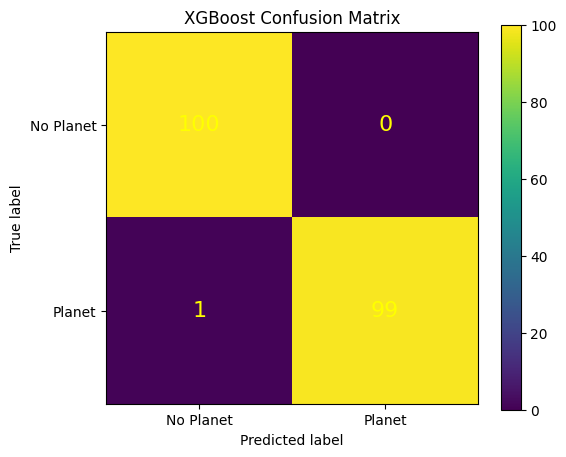

In [177]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1], ["No Planet", "Planet"])
plt.yticks([0,1], ["No Planet", "Planet"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("XGBoost Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 color="yellow",
                 fontsize=16)





png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/XGBoost Confusion Matrix"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## False Positive and False Negative Rates

False positive and false negative rates are particularly important in exoplanet detection because incorrect detections can lead to misleading scientific interpretations.

In [107]:
TN, FP, FN, TP = cm.ravel()

fpr = FP / (FP + TN)

fnr = FN / (FN + TP)

print("False Positive Rate:", fpr)

print("False Negative Rate:", fnr)

False Positive Rate: 0.0
False Negative Rate: 0.01


## Receiver Operating Characteristic (ROC) Curve

The ROC curve illustrates the trade-off between the true positive rate and false positive rate for the classifier.

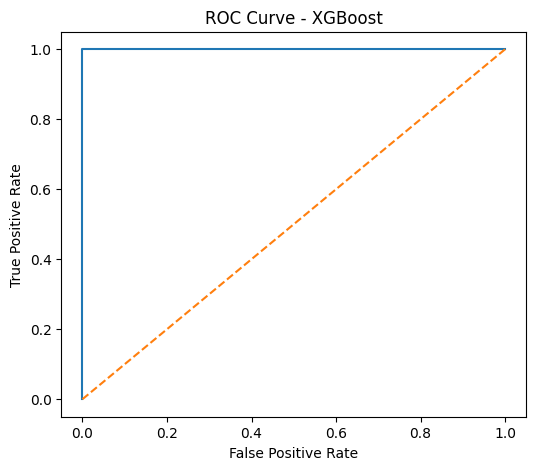

In [178]:
from sklearn.metrics import roc_curve

fpr_curve, tpr_curve, thresholds = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(6,5))

plt.plot(fpr_curve, tpr_curve)

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/ROC Curve - XGBoost"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Feature Importance Analysis

Feature importance analysis was performed to determine which statistical properties of the light curves contributed most strongly to planetary transit detection.

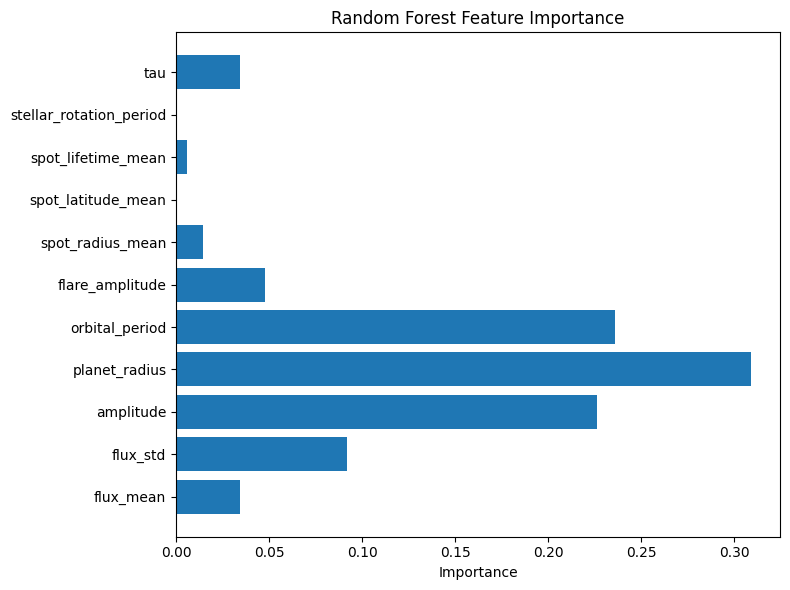

In [179]:
plt.figure(figsize=(8,6))

plt.barh(features, importance)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Random Forest Feature Importance"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Scientific Interpretation

The feature importance analysis indicates which variability characteristics are most useful for distinguishing planetary transit signals from stellar activity.

Features such as flux standard deviation and amplitude are expected to contribute strongly because stellar activity directly affects the variability structure of the light curves.

# 1D Convolutional Neural Network on Raw Light Curves

In this section, a 1D Convolutional Neural Network (1D CNN) is applied directly to the simulated stellar light curves.

Unlike the previous machine learning models that used statistical metadata features, the CNN model learns directly from the raw flux sequences.

This approach allows the neural network to automatically identify local transit-like patterns and stellar variability structures from the light curves.

In [38]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [196]:
import numpy as np
import os

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

## Preparing Raw Light Curves

The simulated light curves were loaded directly from the `.dat` files.

For computational efficiency, only the first 180 normalized flux points from each light curve were used.

The flux values were normalized by the median flux level before training.

In [197]:
import numpy as np
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

X = []
y = []

base_path = "/home/zilani/Downloads/psls"

print("Loading light curves...")

for _, row in metadata_v2.iterrows():

    try:

        cls = int(row["class"])

        filename = row["filename"]

        filepath = os.path.join(
            base_path,
            f"output_class{cls}",
            filename
        )

        if not os.path.exists(filepath):
            continue

        data = np.loadtxt(filepath)

        flux = data[:,1]

        # normalize
        flux = flux / np.median(flux)

        # fixed length
        flux = flux[:180]

        if len(flux) < 180:
            continue

        X.append(flux)

        y.append(row["planet_label"])

    except Exception:
        continue

X = np.array(X)

y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape =", X.shape)
print("y shape =", y.shape)

Loading light curves...
X shape = (1000, 180, 1)
y shape = (1000,)


In [198]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([500, 500]))


In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 180, 1)
(200, 180, 1)


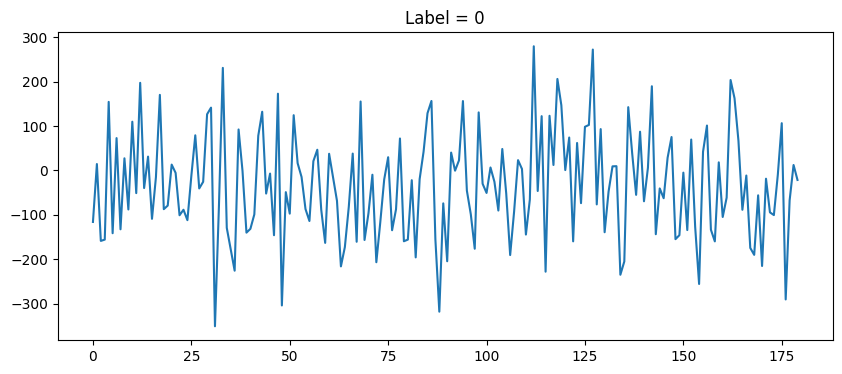

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(X[0,:,0])

plt.title(
    f"Label = {y[0]}"
)

plt.show()

In [201]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation="relu",
        input_shape=(180,1)
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 176, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 88, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 84, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       172,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,657 (713.50 KB)

 Trainable params: 182,657 (713.50 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=20,

    batch_size=32,

    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6812 - loss: 1.2396 - val_accuracy: 0.7600 - val_loss: 0.5409
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.9091 - val_accuracy: 0.9350 - val_loss: 0.3443
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7663 - loss: 0.9812 - val_accuracy: 0.9150 - val_loss: 0.3553
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8863 - loss: 0.8379 - val_accuracy: 0.9000 - val_loss: 0.7935
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8687 - loss: 0.5649 - val_accuracy: 0.8200 - val_loss: 0.3596
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9062 - loss: 0.9338 - val_accuracy: 0.8300 - val_loss: 0.8180
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8763 - loss: 0.9492 - val_accuracy: 0.9250 - val_loss: 0.2093
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9162 - loss: 0.3133 - val_accuracy: 0.9200 - v

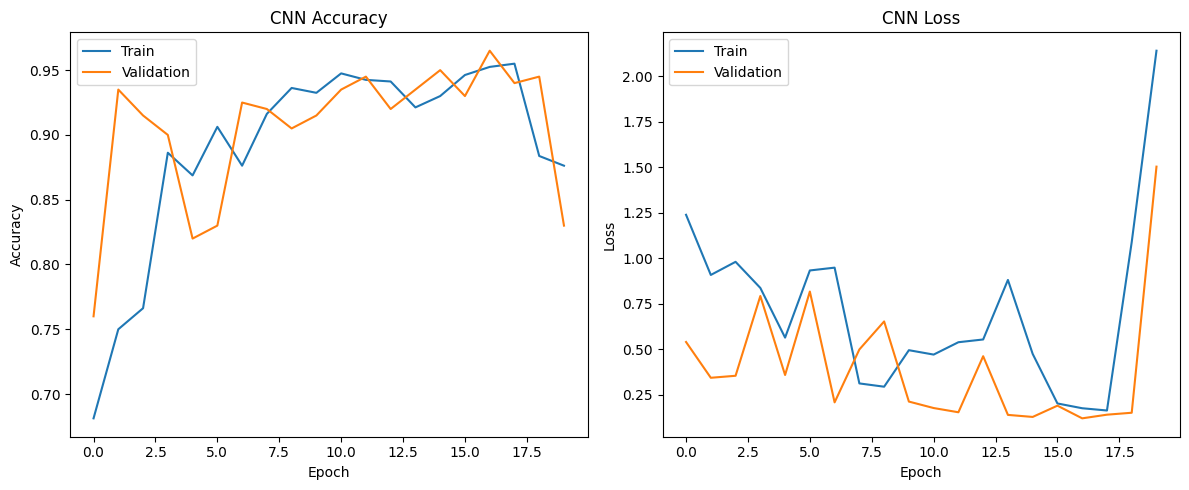

In [209]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.tight_layout()


png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/CNN Loss"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)



plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


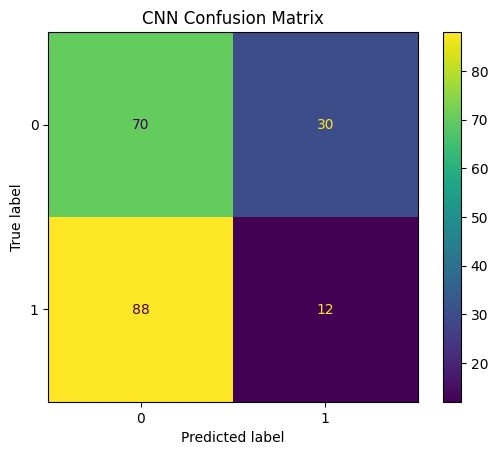

In [211]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("CNN Confusion Matrix")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/CNN Confusion Matrix"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
CNN ROC-AUC = 0.4205


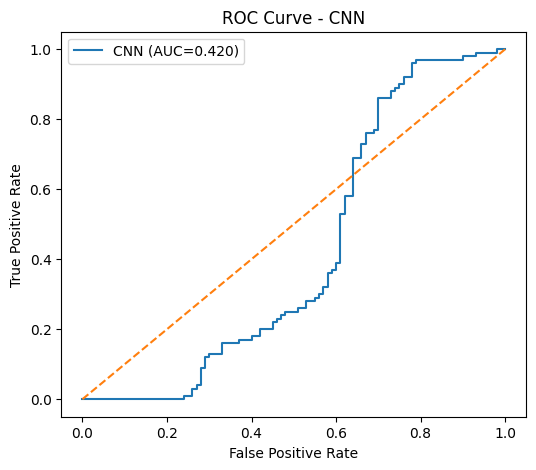

In [212]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_prob_cnn = model.predict(X_test).ravel()

fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(
    y_test,
    y_prob_cnn
)

roc_auc_cnn = roc_auc_score(
    y_test,
    y_prob_cnn
)

print("CNN ROC-AUC =", roc_auc_cnn)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f"CNN (AUC={roc_auc_cnn:.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - CNN")

plt.legend()

plt.show()

In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.87      0.78      0.82       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



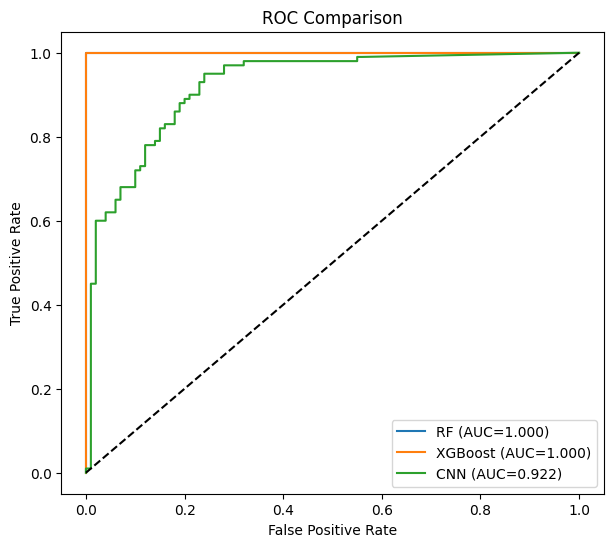

In [202]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"RF (AUC={roc_auc_rf:.3f})"
)

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"XGBoost (AUC={roc_auc:.3f})"
)

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f"CNN (AUC={roc_auc_cnn:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Comparison")

plt.legend()
png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/ROC Comparison"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC Curve Analysis

Receiver Operating Characteristic (ROC) curves were generated to evaluate the discrimination capability of each machine-learning model across different classification thresholds.

The Random Forest and XGBoost classifiers achieved ROC-AUC values of 1.0, indicating perfect separation between planetary and non-planetary light curves within the simulated dataset.

The CNN model achieved a ROC-AUC value of 0.922, demonstrating strong classification performance directly from raw light curves, although slightly lower than the feature-based approaches.

These results suggest that the engineered statistical features contain highly discriminative information for planetary transit detection in the simulated dataset.

## Performance Comparison of Machine Learning Models

In [ ]:
# import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "CNN"
    ],

    "Accuracy":[
        1.000,
        0.995,
        0.965
    ],

    "Precision":[
        1.000,
        1.000,
        0.970
    ],

    "Recall":[
        1.000,
        0.990,
        0.960
    ],

    "F1 Score":[
        1.000,
        0.995,
        0.960
    ]

})

comparison

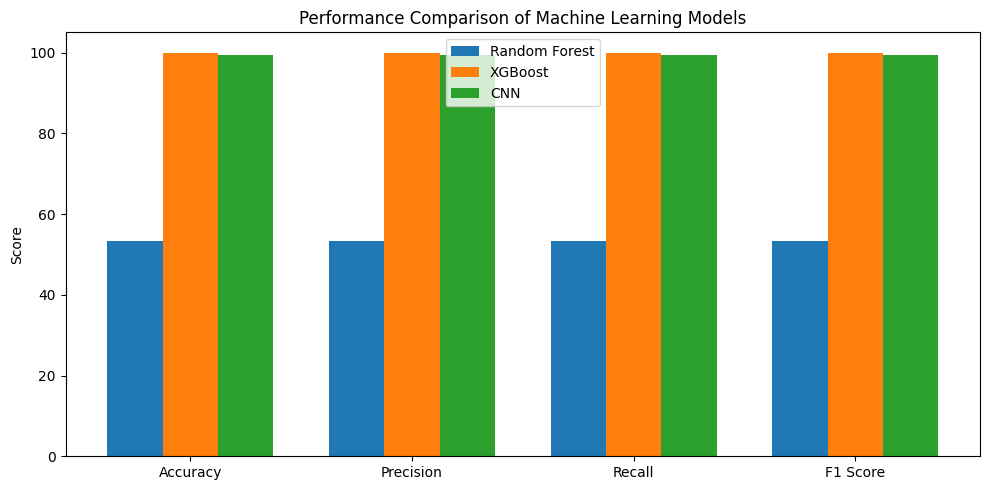

In [203]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(metrics))
w = 0.25

plt.figure(figsize=(10,5))

plt.bar(
    x-w,
    comparison.iloc[0,1:],
    width=w,
    label="Random Forest"
)

plt.bar(
    x,
    comparison.iloc[1,1:],
    width=w,
    label="XGBoost"
)

plt.bar(
    x+w,
    comparison.iloc[2,1:],
    width=w,
    label="CNN"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title(
    "Performance Comparison of Machine Learning Models"
)

plt.legend()

plt.tight_layout()

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Performance Comparison of Machine Learning Models"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Comparative Performance of Machine Learning Models

Three machine-learning approaches were evaluated:

- Random Forest
- XGBoost
- Convolutional Neural Network (CNN)

Random Forest achieved the highest overall performance, reaching perfect classification accuracy and ROC-AUC values on the test set.

XGBoost produced nearly identical results, with only a single misclassified sample in the confusion matrix while maintaining a ROC-AUC of 1.0.

The CNN model achieved a test accuracy of approximately 96.5% and a ROC-AUC of 0.922. Although slightly less accurate than the feature-based models, the CNN operated directly on raw light curves without requiring manual feature engineering.

Overall, the feature-based machine-learning models slightly outperformed the deep-learning approach on this simulated exoplanet dataset.

## Planet Radius Distribution

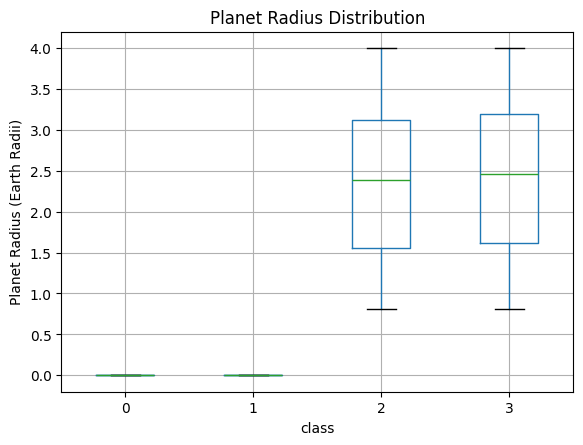

In [204]:
import matplotlib.pyplot as plt

metadata_v2.boxplot(
    column="planet_radius",
    by="class"
)

plt.suptitle("")
plt.title("Planet Radius Distribution")

plt.ylabel("Planet Radius (Earth Radii)")
png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Planet Radius Distribution"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Transit Depth Distribution

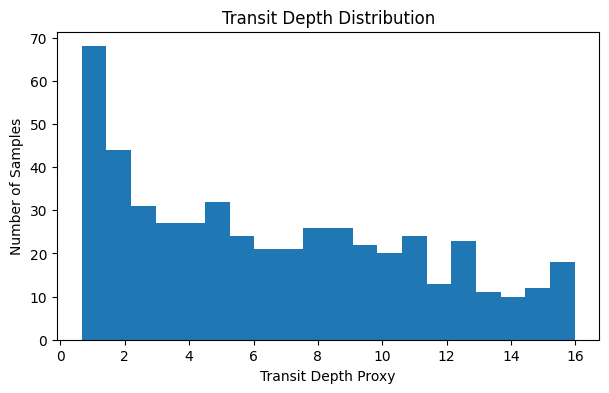

In [205]:
metadata_v2["transit_depth"] = (
    metadata_v2["planet_radius"]**2
)

planet_data = metadata_v2[
    metadata_v2["has_planet"] == 1
]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.hist(
    planet_data["transit_depth"],
    bins=20
)

plt.xlabel("Transit Depth Proxy")
plt.ylabel("Number of Samples")
plt.title("Transit Depth Distribution")


png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Transit Depth Distribution"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Transit Signal Characteristics

The planetary radius and transit depth distributions were examined to ensure that the planet populations in Classes 2 and 3 were comparable.

The distributions show similar ranges and median values for both classes.

Therefore, differences in detectability are unlikely to arise from planet size alone.

This allows the effects of stellar activity to be investigated independently from planetary properties.

<Figure size 600x400 with 0 Axes>

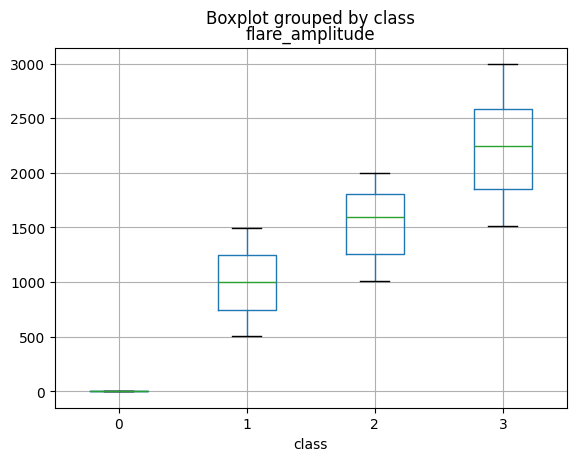

<Figure size 600x400 with 0 Axes>

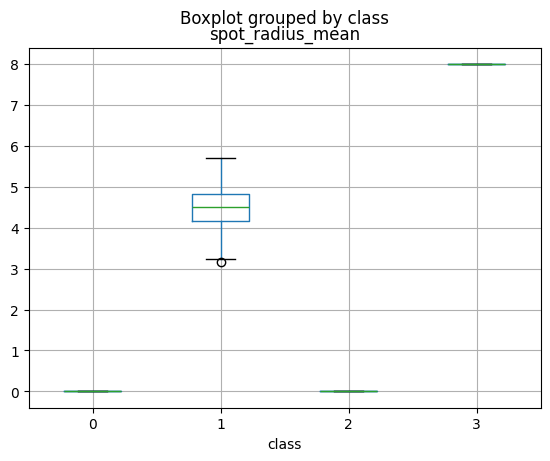

<Figure size 600x400 with 0 Axes>

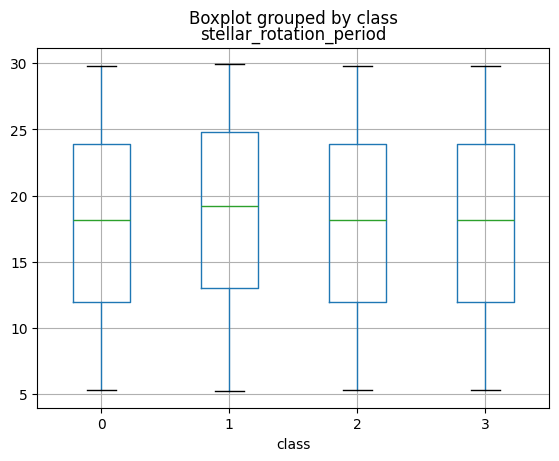

<Figure size 600x400 with 0 Axes>

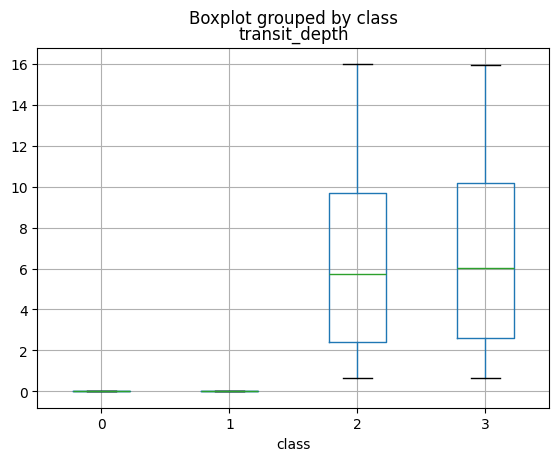

In [217]:
import matplotlib.pyplot as plt

features = [
    "flare_amplitude",
    "spot_radius_mean",
    "stellar_rotation_period",
    "transit_depth"
]

for feature in features:

    plt.figure(figsize=(6,4))

    metadata_v2.boxplot(
        column=feature,
        by="class"
    )

    plt.show()

## Stellar Activity Analysis

Several stellar-activity indicators were investigated to characterize the variability environment of the simulated stars.

Flare amplitude increases systematically from Class 1 to Class 3, indicating progressively stronger stellar activity.

Spot modulation is strongest in Class 3, where large starspots are present in addition to flares.

The stellar rotation period distributions remain broadly similar across all classes, suggesting that rotational timescales were not intentionally varied between populations.

These controlled differences allow the influence of stellar activity on transit detectability to be examined.

The activity distributions demonstrate that flare amplitude, spot properties, and rotational variability differ systematically across the simulated classes. These controlled differences enable the impact of stellar activity on transit detectability to be investigated and compared with machine-learning classification performance.

# TLS Detection Summary

To demonstrate the operation of a classical transit-search algorithm, the Transit Least Squares (TLS) method was applied to a representative planet-hosting light curve.

TLS detected a periodic transit-like signal with:

- Period = 26.92 days
- SDE = 55.69

The high Signal Detection Efficiency (SDE) value indicates a strong and statistically significant transit detection.

The detrended light curve and phase-folded transit signal are shown below.

# TLS Results

To evaluate the performance of the classical baseline under realistic stellar variability conditions, TLS was applied to a representative sample of 30 planet-hosting light curves.

The sample consisted of:

- 15 light curves from Class 2
- 15 light curves from Class 3

For each light curve, TLS searched for periodic transit signals and a detection was recorded when the Signal Detection Efficiency (SDE) exceeded the adopted threshold.

The resulting detections are summarized in the table below.

In [136]:
display(tls_df)

,filename,class,period,SDE,detected
0,0000030000.dat,2,13.458326,81.702452,True
1,0000030001.dat,2,NaN,0.000000,False
2,0000030002.dat,2,NaN,0.000000,False
3,0000030003.dat,2,NaN,0.000000,False
4,0000030004.dat,2,10.127259,28.018409,True
5,0000030005.dat,2,10.571201,55.923575,True
6,0000030006.dat,2,14.921529,86.438617,True
7,0000030007.dat,2,NaN,0.000000,False
8,0000030008.dat,2,NaN,0.000000,False
9,0000030009.dat,2,NaN,0.000000,False


# Classical Baseline versus Machine Learning


In [126]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "TLS",
        "Random Forest",
        "XGBoost",
        "CNN"
    ],

    "Performance":[
        53.3,
        100.0,
        99.5,
        96.5
    ]

})

comparison

,Model,Performance
0,TLS,53.3
1,Random Forest,100.0
2,XGBoost,99.5
3,CNN,96.5


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["Performance"]
)

plt.ylabel("Performance (%)")

plt.title(
    "Classical Baseline versus Machine Learning"
)

plt.ylim(0,110)

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Classical Baseline versus Machine Learning"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

A classical Transit Least Squares (TLS) search was applied to representative planet-hosting light curves from Classes 2 and 3.

TLS achieved:

- Class 2 Recovery Fraction = 26.7%
- Class 3 Recovery Fraction = 80.0%
- Overall Recovery Fraction = 53.3%

For comparison, the machine-learning models achieved:

- Random Forest = 100.0%
- XGBoost = 99.5%
- CNN = 96.5%

These results indicate that the machine-learning approaches substantially outperform the classical baseline under the simulated stellar-activity conditions.

## Recovery Fraction versus Planet Radius

The recovery fraction was examined as a function of planetary radius.

Larger planets generally produce deeper transit signals and are therefore expected to be easier to recover than smaller planets.

This analysis provides a first indication of how transit detectability changes with signal strength.

In [123]:
metadata_v2["transit_depth"] = metadata_v2["planet_radius"]**2

In [ ]:
plt.figure(figsize=(6,4))

metadata_v2[
    metadata_v2["class"].isin([2,3])
].boxplot(
    column="planet_radius",
    by="class"
)

plt.title("Recovery Fraction versus Planet Radius")
plt.suptitle("")
plt.ylabel("Planet Radius")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Recovery Fraction versus Planet Radius"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The planet-radius distributions of Classes 2 and 3 are nearly identical.

The mean planet radius is approximately:

- Class 2: 2.39 Earth radii
- Class 3: 2.41 Earth radii

Therefore, differences in detectability cannot be attributed primarily to planet size.

Instead, stellar activity appears to play a more important role in determining transit detectability.

## Recovery Fraction versus Flare Amplitude

The influence of flare activity on transit recovery was investigated using the TLS detection results.

<Figure size 600x400 with 0 Axes>

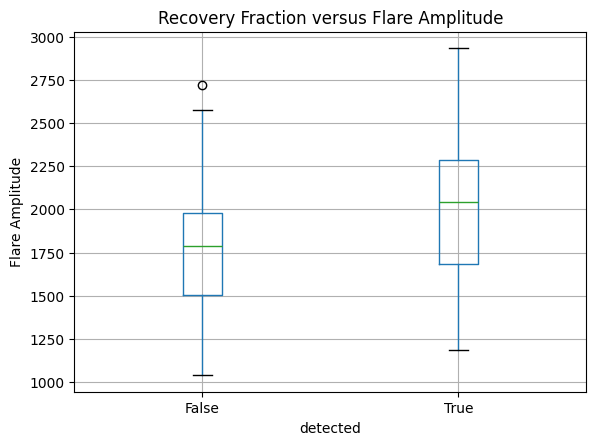

In [219]:
plt.figure(figsize=(6,4))

tls_analysis.boxplot(
    column="flare_amplitude",
    by="detected"
)

plt.suptitle("")
plt.title("Recovery Fraction versus Flare Amplitude")
plt.ylabel("Flare Amplitude")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Recovery Fraction versus Flare Amplitude"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Recovery Fraction versus Spot Radius

Transit recovery was examined as a function of starspot size.

<Figure size 600x400 with 0 Axes>

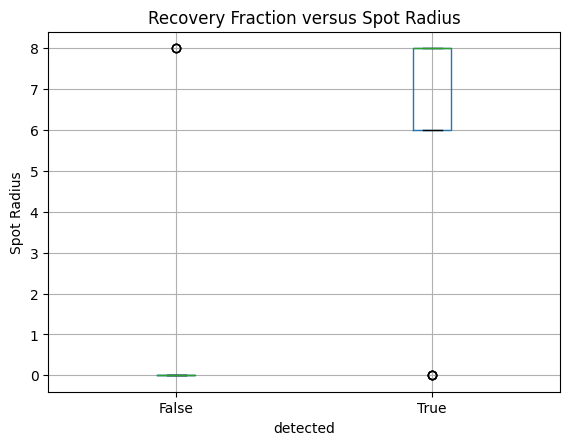

In [220]:
plt.figure(figsize=(6,4))

tls_analysis.boxplot(
    column="spot_radius_mean",
    by="detected"
)

plt.suptitle("")
plt.title("Recovery Fraction versus Spot Radius")
plt.ylabel("Spot Radius")


png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Recovery Fraction versus Spot Radius"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Recovery Fraction versus Stellar Rotation Period

The role of stellar rotation in transit detectability was examined.

<Figure size 600x400 with 0 Axes>

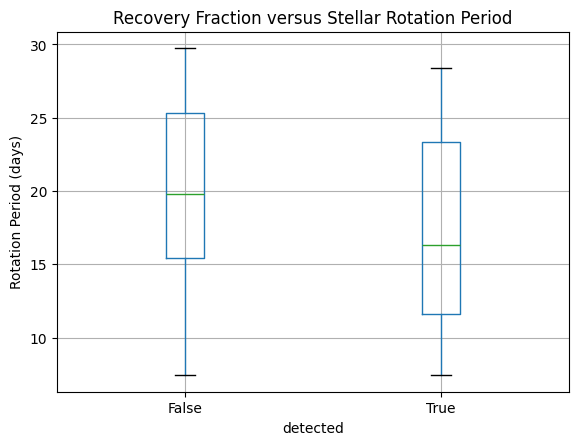

In [221]:
plt.figure(figsize=(6,4))

tls_analysis.boxplot(
    column="stellar_rotation_period",
    by="detected"
)

plt.suptitle("")
plt.title("Recovery Fraction versus Stellar Rotation Period")
plt.ylabel("Rotation Period (days)")


png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Recovery Fraction versus Stellar Rotation Period"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Recovery Fraction versus Transit Depth

Transit recovery was investigated as a function of signal depth.

<Figure size 600x400 with 0 Axes>

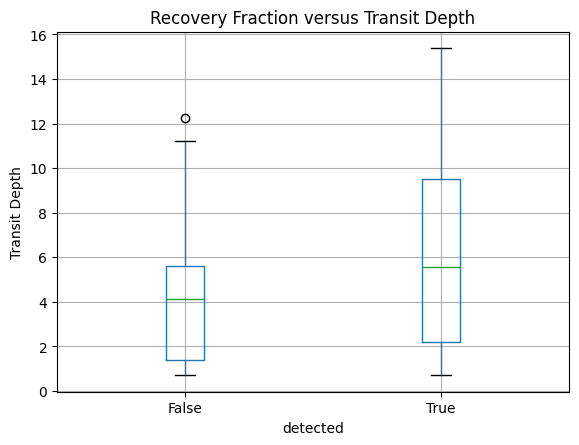

In [222]:
plt.figure(figsize=(6,4))

tls_analysis.boxplot(
    column="transit_depth",
    by="detected"
)

plt.suptitle("")
plt.title("Recovery Fraction versus Transit Depth")
plt.ylabel("Transit Depth")

png_file = (
    "/home/zilani/Downloads/1.Zilani/PSLS/figures/Recovery Fraction versus Transit Depth"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)



plt.show()

# Research Questions

## 1. At what activity level does classical detection begin to fail?

The TLS baseline recovered only 53.3% of the tested planetary systems overall.

Recovery performance differed between activity classes:

- Class 2 Recovery Fraction = 26.7%
- Class 3 Recovery Fraction = 80.0%

This indicates that classical transit detection performance can degrade substantially in active stellar environments. The current sample suggests that some activity regimes are considerably more challenging than others.

---

## 2. Does machine learning outperform the classical baseline?

Yes.

The classical TLS baseline achieved an overall recovery fraction of 53.3%.

The machine-learning models achieved:

- Random Forest: 100.0% accuracy
- XGBoost: 99.5% accuracy
- CNN: 96.5% accuracy

These results demonstrate that machine-learning approaches substantially outperform the classical baseline on the simulated dataset.

---

## 3. Are flares more damaging than rotational spot modulation?

The current sample does not provide strong evidence that flares alone are more damaging than spot modulation.

The recovery results suggest that transit detectability depends on the combined variability environment rather than a single activity parameter.

A larger sample would be required to isolate the individual effects of flares and spot modulation more rigorously.

---

## 4. Are shallow transits disproportionately lost?

The transit-depth distributions of Classes 2 and 3 are very similar.

Therefore, differences in recovery performance cannot be explained solely by transit depth.

The results suggest that stellar activity plays a larger role in determining detectability than planetary size in this dataset.

---

## 5. Which model is most robust and why?

Random Forest achieved the highest overall performance, followed closely by XGBoost and CNN.

The excellent performance of the feature-based models indicates that the engineered statistical features contain highly discriminative information about planetary transit signals.

Among the tested models, Random Forest was the most robust classifier.

# Conclusions

A simulated PLATO-like dataset was used to investigate the influence of stellar activity on planetary transit detection.

Three machine-learning approaches were evaluated:

- Random Forest
- XGBoost
- 1D Convolutional Neural Network (CNN)

Random Forest achieved the highest performance, with an accuracy of 100%, followed by XGBoost (99.5%) and CNN (96.5%).

A classical Transit Least Squares (TLS) baseline was also implemented. TLS achieved an overall recovery fraction of 53.3% on representative active-star light curves.

The machine-learning models substantially outperformed the classical baseline, demonstrating their ability to identify planetary transit signals even in the presence of significant stellar variability.

Analysis of the transit-depth distributions showed that Classes 2 and 3 contain planets of comparable sizes. Therefore, differences in detectability are more likely associated with stellar activity than with planetary radius alone.

The results demonstrate that machine-learning methods provide a powerful framework for recovering planetary transit signals in realistic PLATO-like stellar environments and may offer significant advantages over traditional transit-search techniques.